# 00_Detect_Sigh

Edi 기반 sigh candidate를 시각적으로 점검하기 위한 노트북입니다.
- peak/apnea는 기존 `moving_window_detect_all_patients.py` 로직을 재사용
- sigh는 `detect_sigh_candidates` 결과(`detected_sigh`)를 확인


In [15]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

from moving_window_detect_all_patients import (
    FS,
    BASELINE_WIN_SEC,
    SMOOTH_WIN_SEC,
    LOCAL_STD_WIN_SEC,
    APNEA_MIN_SEC,
    MIN_PEAK_DIST_SEC,
    MIN_BREATH_SEC,
    MAX_BREATH_SEC,
    LOW_STD_QUANTILE,
    PROM_FACTOR,
    SIGH_N_BREATHS,
    SIGH_REL_FACTOR,
    SIGH_ABS_QUANTILE,
    SIGH_MERGE_SEC,
    IGNORE_HEAD_SEC as DEFAULT_IGNORE_HEAD_SEC,
    IGNORE_TAIL_SEC as DEFAULT_IGNORE_TAIL_SEC,
    normalize_patient_id,
    resolve_columns,
    infer_time_seconds,
    rolling_centered_median,
    rolling_centered_mean,
    rolling_centered_std,
    mark_long_runs,
    detect_sigh_candidates,
)

plt.rcParams['figure.figsize'] = (16, 4)
plt.rcParams['axes.grid'] = True


In [16]:
# ---- 설정 ----
RAW_DIR = Path('/home/jhkim/NAVA/02_YOLO/data/1_Refined_Raw')
PATIENT_ID = '08'  # e.g. '01', '02', ...

# sigh sensitivity 튜닝
N_BREATHS = SIGH_N_BREATHS
REL_FACTOR = SIGH_REL_FACTOR
ABS_QUANTILE = SIGH_ABS_QUANTILE
MERGE_SEC = SIGH_MERGE_SEC
EDI_BASELINE_WIN_SEC = None  # 예: 20.0 으로 주면 baseline 제거

# 파일 시작/끝 제외 구간
IGNORE_HEAD_SEC = DEFAULT_IGNORE_HEAD_SEC
IGNORE_TAIL_SEC = DEFAULT_IGNORE_TAIL_SEC

# 시각화 설정
FULL_FIG_SEC_LIMIT = 600  # 전체 그림이 너무 길면 앞쪽 N초만 표시
WINDOW_SEC = 60
MAX_WINDOWS = 5


In [17]:
pid = normalize_patient_id(PATIENT_ID)
raw_file = RAW_DIR / f'{pid}.xlsx'
if not raw_file.exists():
    raise FileNotFoundError(f'Raw file not found: {raw_file}')

raw = pd.read_excel(raw_file)
ts_col, resp_col, edi_col, raw = resolve_columns(raw)

df = raw[[ts_col, resp_col, edi_col]].copy().dropna().reset_index(drop=True)
df.columns = ['timestamp', 'resp', 'edi']
df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
df['resp'] = pd.to_numeric(df['resp'], errors='coerce')
df['edi'] = pd.to_numeric(df['edi'], errors='coerce')
df = df.dropna().reset_index(drop=True)

raw_ts = df['timestamp'].to_numpy(dtype=float)
t_sec = infer_time_seconds(raw_ts, FS)
resp_raw = df['resp'].to_numpy(dtype=float)
edi_raw = df['edi'].to_numpy(dtype=float)

ignore_head_sec = float(max(0.0, IGNORE_HEAD_SEC))
ignore_tail_sec = float(max(0.0, IGNORE_TAIL_SEC))
t0 = float(t_sec[0]) if len(t_sec) > 0 else 0.0
t1 = float(t_sec[-1]) if len(t_sec) > 0 else 0.0
valid_mask = (t_sec >= (t0 + ignore_head_sec)) & (t_sec <= (t1 - ignore_tail_sec))

# peak/apnea: 기존 detect_for_patient과 동일 로직
baseline = rolling_centered_median(resp_raw, int(BASELINE_WIN_SEC * FS))
resp_detrended = resp_raw - baseline
resp_proc = rolling_centered_mean(resp_detrended, int(SMOOTH_WIN_SEC * FS))

local_std = rolling_centered_std(resp_proc, int(LOCAL_STD_WIN_SEC * FS))
std_ref = local_std[np.isfinite(local_std) & valid_mask]
if len(std_ref) == 0:
    std_ref = local_std[np.isfinite(local_std)]
low_std_thr = float(np.quantile(std_ref, LOW_STD_QUANTILE))
apnea_mask = mark_long_runs(local_std <= low_std_thr, int(APNEA_MIN_SEC * FS))
apnea_mask &= valid_mask

non_apnea_std = local_std[~apnea_mask]
non_apnea_std = non_apnea_std[np.isfinite(non_apnea_std) & valid_mask[~apnea_mask]]
if len(non_apnea_std) == 0:
    peak_idx = np.array([], dtype=int)
    prominence_min = float('nan')
else:
    prominence_min = float(np.median(non_apnea_std) * PROM_FACTOR)
    peak_idx, _ = find_peaks(
        resp_proc,
        distance=int(MIN_PEAK_DIST_SEC * FS),
        prominence=prominence_min,
    )
    peak_idx = peak_idx[~apnea_mask[peak_idx]]
    peak_idx = peak_idx[valid_mask[peak_idx]]
    if len(peak_idx) >= 2:
        d = np.diff(peak_idx)
        keep = np.ones(len(peak_idx), dtype=bool)
        keep[1:] &= (d >= int(MIN_BREATH_SEC * FS)) & (d <= int(MAX_BREATH_SEC * FS))
        peak_idx = peak_idx[keep]

sigh_mask, sigh_params = detect_sigh_candidates(
    edi_raw=edi_raw,
    peak_idx=peak_idx,
    apnea_mask=apnea_mask,
    fs=FS,
    n_breaths=N_BREATHS,
    rel_factor=REL_FACTOR,
    abs_quantile=ABS_QUANTILE,
    merge_sec=MERGE_SEC,
    edi_baseline_win_sec=EDI_BASELINE_WIN_SEC,
)
sigh_idx = np.flatnonzero(sigh_mask)

print(f'Patient: {pid} | rows={len(df)} | duration={t_sec[-1]-t_sec[0]:.1f}s')
print(f'ignored: head={ignore_head_sec:.1f}s, tail={ignore_tail_sec:.1f}s | valid_ratio={valid_mask.mean():.4f}')
print(f'detected_peak={len(peak_idx)} | apnea_ratio={apnea_mask.mean():.4f}')
print(f'detected_sigh={len(sigh_idx)} | params={sigh_params}')


Patient: 08 | rows=400000 | duration=4003.4s
ignored: head=10.0s, tail=10.0s | valid_ratio=0.9950
detected_peak=1647 | apnea_ratio=0.0123
detected_sigh=156 | params={'sigh_n_breaths': 20, 'sigh_rel_factor': 1.8, 'sigh_abs_quantile': 0.95, 'sigh_abs_threshold': 38.03, 'sigh_merge_sec': 0.5, 'n_sigh_candidates': 156, 'sigh_candidate_ratio': 0.09477521263669501, 'sigh_breath_count': 1646, 'sigh_eligible_breath_count': 1641, 'n_sigh_raw_before_merge': 265}


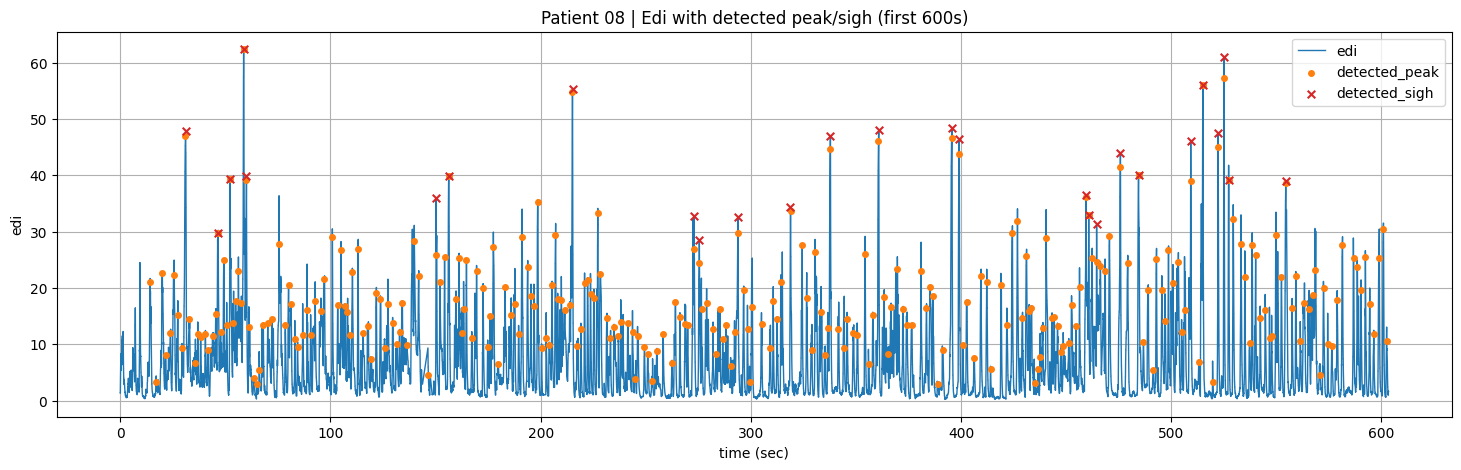

In [18]:
# ---- 전체 시각화 (앞쪽 일부 구간) ----
i0 = 0
i1 = min(len(df), int(FULL_FIG_SEC_LIMIT * FS))

t = t_sec[i0:i1]
edi = edi_raw[i0:i1]
ap = apnea_mask[i0:i1]

peak_win = peak_idx[(peak_idx >= i0) & (peak_idx < i1)]
sigh_win = sigh_idx[(sigh_idx >= i0) & (sigh_idx < i1)]

fig, ax = plt.subplots(1, 1, figsize=(18, 5))
ax.plot(t, edi, lw=1.0, color='tab:blue', label='edi')

if len(peak_win) > 0:
    ax.scatter(t_sec[peak_win], edi_raw[peak_win], s=16, color='tab:orange', label='detected_peak', zorder=3)
if len(sigh_win) > 0:
    ax.scatter(t_sec[sigh_win], edi_raw[sigh_win], s=30, marker='x', color='tab:red', label='detected_sigh', zorder=4)

# apnea shading
in_run = False
start = 0
for k, flag in enumerate(ap):
    if flag and not in_run:
        start = k
        in_run = True
    elif (not flag) and in_run:
        ax.axvspan(t[start], t[k-1], color='gray', alpha=0.2)
        in_run = False
if in_run:
    ax.axvspan(t[start], t[-1], color='gray', alpha=0.2, label='apnea')

ax.set_title(f'Patient {pid} | Edi with detected peak/sigh (first {FULL_FIG_SEC_LIMIT}s)')
ax.set_xlabel('time (sec)')
ax.set_ylabel('edi')
ax.legend(loc='upper right')
plt.show()


In [19]:
def plot_window(center_idx: int, window_sec: int = 60):
    half = int(window_sec * FS / 2)
    i0 = max(0, center_idx - half)
    i1 = min(len(df), center_idx + half)

    t = t_sec[i0:i1]
    edi = edi_raw[i0:i1]
    ap = apnea_mask[i0:i1]

    peak_win = peak_idx[(peak_idx >= i0) & (peak_idx < i1)]
    sigh_win = sigh_idx[(sigh_idx >= i0) & (sigh_idx < i1)]

    fig, ax = plt.subplots(1, 1, figsize=(16, 4))
    ax.plot(t, edi, lw=1.2, color='tab:blue', label='edi')

    if len(peak_win) > 0:
        ax.scatter(t_sec[peak_win], edi_raw[peak_win], s=20, color='tab:orange', label='detected_peak', zorder=3)
    if len(sigh_win) > 0:
        ax.scatter(t_sec[sigh_win], edi_raw[sigh_win], s=45, marker='x', color='tab:red', label='detected_sigh', zorder=4)

    in_run = False
    start = 0
    for k, flag in enumerate(ap):
        if flag and not in_run:
            start = k
            in_run = True
        elif (not flag) and in_run:
            ax.axvspan(t[start], t[k-1], color='gray', alpha=0.2)
            in_run = False
    if in_run:
        ax.axvspan(t[start], t[-1], color='gray', alpha=0.2)

    ax.axvline(t_sec[center_idx], ls='--', lw=1.5, color='tab:red', label='current_sigh')
    ax.set_title(f'window={window_sec}s | center={t_sec[center_idx]:.2f}s')
    ax.set_xlabel('time (sec)')
    ax.set_ylabel('edi')
    ax.legend(loc='upper right')
    plt.show()


5개 sigh 후보를 순서대로 표시합니다.
[1] sample_idx=3108, t=31.080s


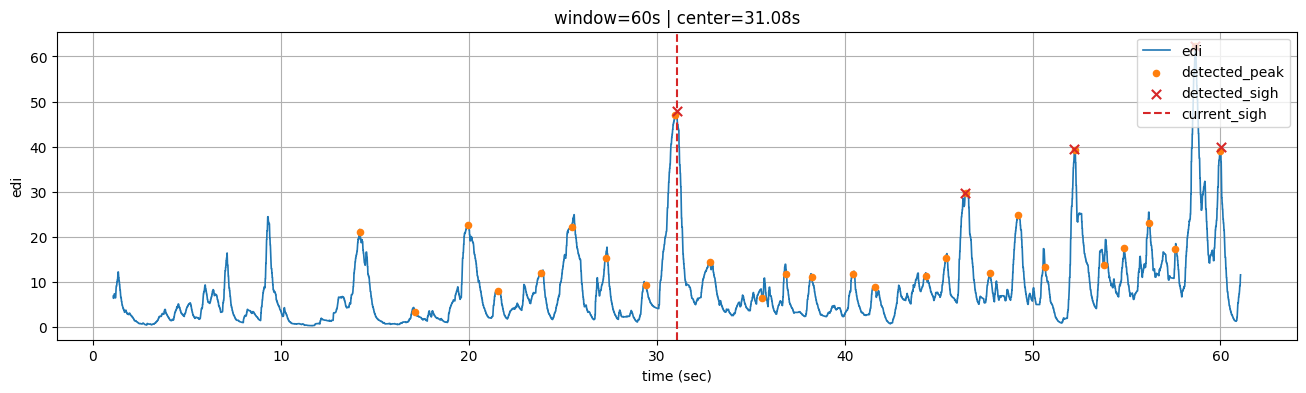

[2] sample_idx=4642, t=46.420s


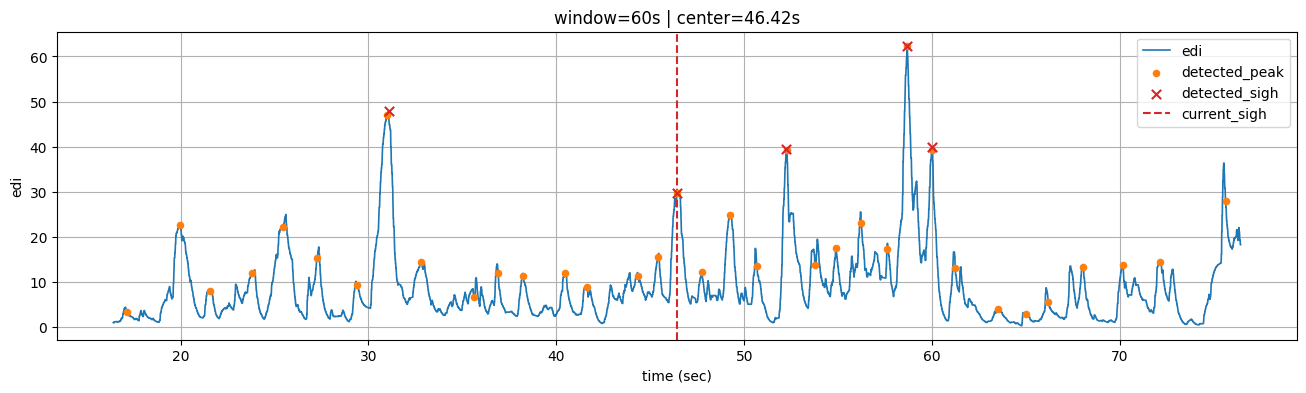

[3] sample_idx=5223, t=52.230s


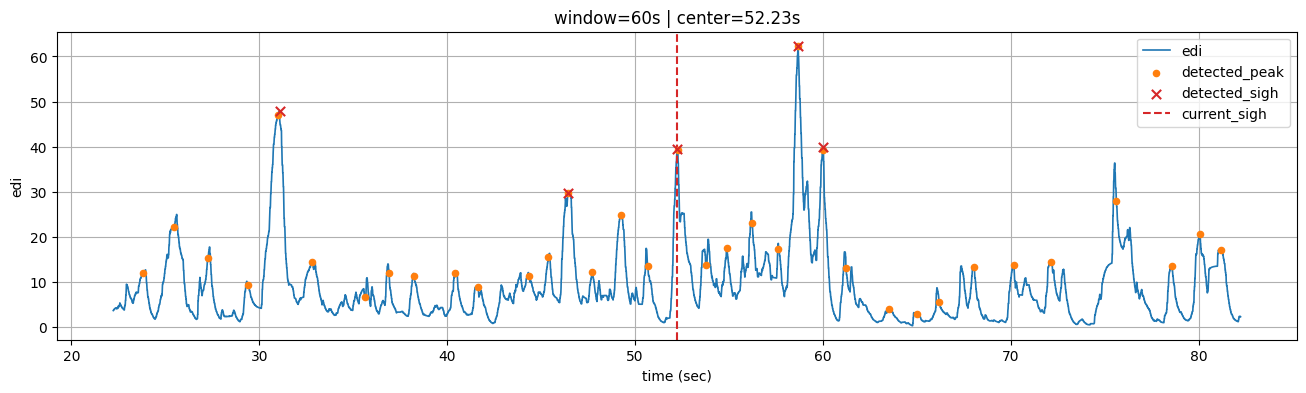

[4] sample_idx=5867, t=58.670s


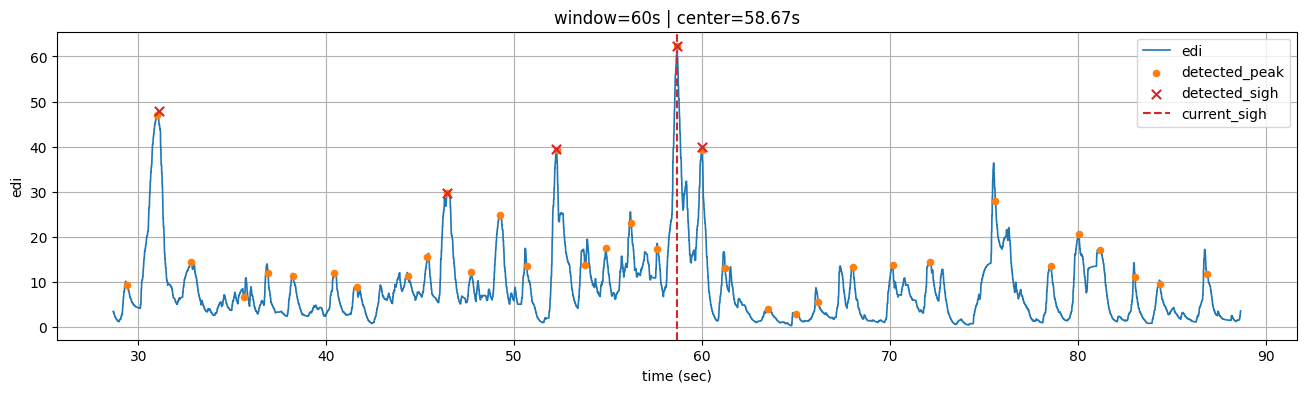

[5] sample_idx=6001, t=60.010s


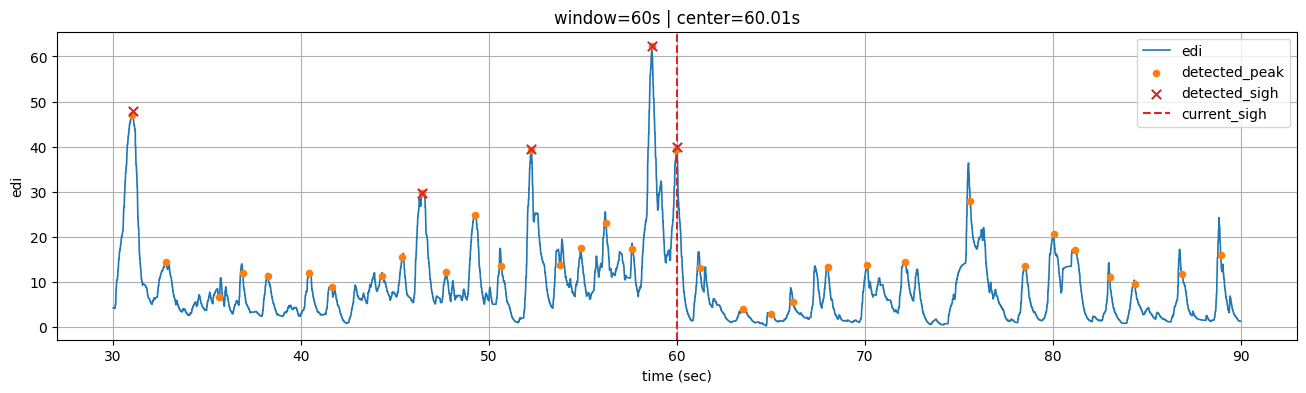

In [20]:
# ---- sigh 후보 확대 보기 ----
if len(sigh_idx) == 0:
    print('detected_sigh가 없습니다.')
else:
    n_show = min(MAX_WINDOWS, len(sigh_idx))
    print(f'{n_show}개 sigh 후보를 순서대로 표시합니다.')
    for k in range(n_show):
        print(f'[{k+1}] sample_idx={sigh_idx[k]}, t={t_sec[sigh_idx[k]]:.3f}s')
        plot_window(int(sigh_idx[k]), WINDOW_SEC)


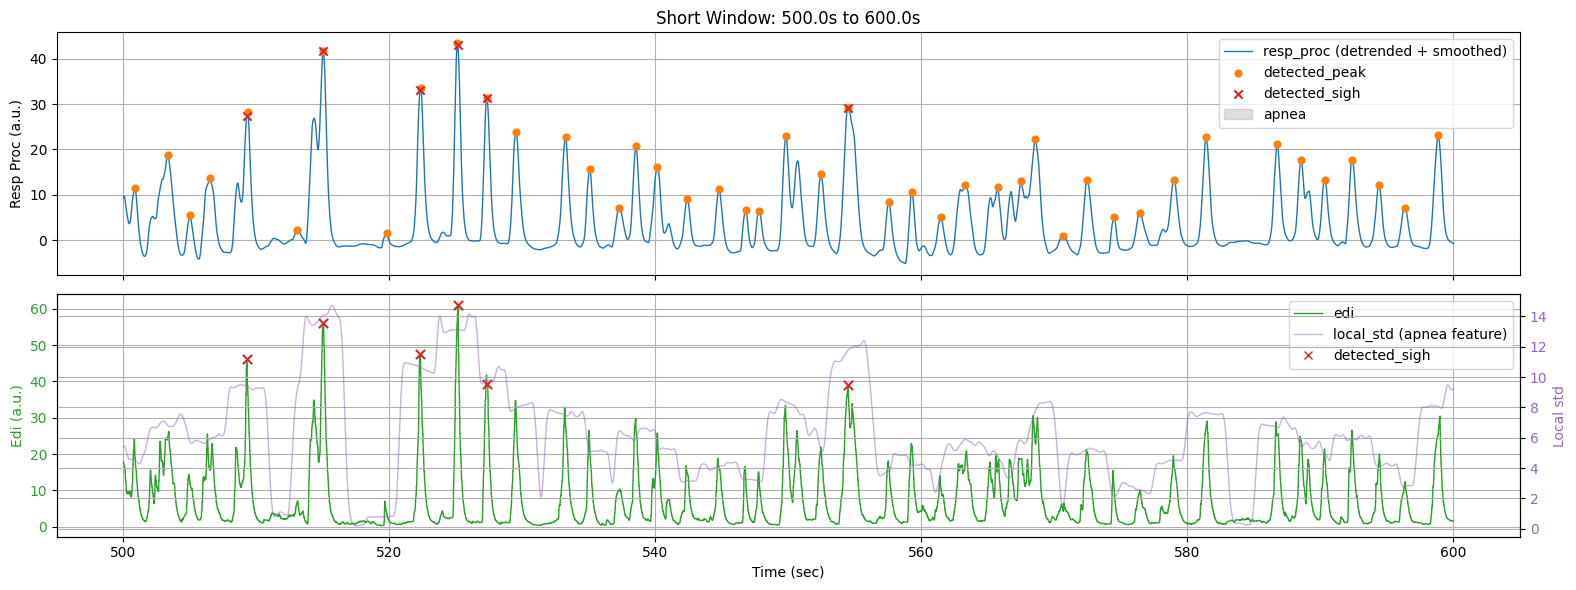

In [21]:
# ---- 원하는 구간 시각화 (00_Detect_Peak 스타일) ----
def plot_short_window(start_time: float, end_time: float):
    if end_time <= start_time:
        raise ValueError('end_time must be greater than start_time.')

    window_mask = (t_sec >= start_time) & (t_sec <= end_time)
    if not np.any(window_mask):
        raise ValueError('No samples in the requested time window.')

    idx = np.where(window_mask)[0]
    i0, i1 = int(idx[0]), int(idx[-1])

    t_win = t_sec[i0:i1 + 1]
    resp_win = resp_proc[i0:i1 + 1]
    edi_win = edi_raw[i0:i1 + 1]
    std_win = local_std[i0:i1 + 1]
    apnea_win = apnea_mask[i0:i1 + 1]

    peak_win = peak_idx[(peak_idx >= i0) & (peak_idx <= i1)]
    sigh_win = sigh_idx[(sigh_idx >= i0) & (sigh_idx <= i1)]

    fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

    # (1) processed resp + peak/sigh
    axes[0].plot(t_win, resp_win, lw=1.0, color='tab:blue', label='resp_proc (detrended + smoothed)')
    if len(peak_win) > 0:
        axes[0].scatter(t_sec[peak_win], resp_proc[peak_win], s=24, color='tab:orange', label='detected_peak', zorder=3)
    if len(sigh_win) > 0:
        axes[0].scatter(t_sec[sigh_win], resp_proc[sigh_win], s=36, marker='x', color='tab:red', label='detected_sigh', zorder=4)

    # apnea shading in selected window
    in_run = False
    start = None
    for j, flag in enumerate(apnea_win):
        if flag and not in_run:
            in_run = True
            start = j
        elif (not flag) and in_run:
            axes[0].axvspan(t_win[start], t_win[j - 1], color='gray', alpha=0.25)
            axes[1].axvspan(t_win[start], t_win[j - 1], color='gray', alpha=0.25)
            in_run = False
    if in_run:
        axes[0].axvspan(t_win[start], t_win[-1], color='gray', alpha=0.25, label='apnea')
        axes[1].axvspan(t_win[start], t_win[-1], color='gray', alpha=0.25)
    else:
        axes[0].axvspan(np.nan, np.nan, color='gray', alpha=0.25, label='apnea')

    axes[0].set_ylabel('Resp Proc (a.u.)')
    axes[0].set_title(f'Short Window: {start_time:.1f}s to {end_time:.1f}s')
    axes[0].legend(loc='upper right')

    # (2) Edi + local std
    l1 = axes[1].plot(t_win, edi_win, lw=1.0, color='tab:green', label='edi')
    axes[1].set_xlabel('Time (sec)')
    axes[1].set_ylabel('Edi (a.u.)', color='tab:green')
    axes[1].tick_params(axis='y', labelcolor='tab:green')

    ax_std = axes[1].twinx()
    l2 = ax_std.plot(t_win, std_win, lw=1.0, color='tab:purple', alpha=0.5, label='local_std (apnea feature)')
    ax_std.set_ylabel('Local std', color='tab:purple')
    ax_std.tick_params(axis='y', labelcolor='tab:purple')

    # sigh points on Edi panel
    if len(sigh_win) > 0:
        axes[1].scatter(t_sec[sigh_win], edi_raw[sigh_win], s=44, marker='x', color='tab:red', label='detected_sigh', zorder=4)

    lines = l1 + l2
    labels = [line.get_label() for line in lines]
    if len(sigh_win) > 0:
        from matplotlib.lines import Line2D
        lines = lines + [Line2D([0], [0], marker='x', color='tab:red', linestyle='None', label='detected_sigh')]
        labels = labels + ['detected_sigh']
    axes[1].legend(lines, labels, loc='upper right')

    plt.tight_layout()
    plt.show()


# Example usage: 원하는 구간으로 수정해서 실행
start_time = 500.0
end_time = start_time + 100.0
plot_short_window(start_time, end_time)

